# Creating Graphs from model results

In this notebook, first the model created by model.ipynb is imported and then the visualisations are created.

## importing requried packages

In [504]:
import linopy
import pypsa

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

import cartopy
import cartopy.crs as ccrs

import networkx as nx

import atlite
from atlite.gis import ExclusionContainer, shape_availability
from rasterio.plot import show
from rasterio.crs import CRS
import rasterio as rio

from pathlib import Path
import xarray as xr

import plotly.io as pio
import plotly.offline as py

pd.options.plotting.backend = "plotly" # or "plotly" or "matplotlib"

## Importing the models

In [505]:
n = pypsa.Network("pypsa_model_n.nc") # the model without CO2 limitations
n_no_co2 = pypsa.Network("pypsa_model_n_no_co2.nc") # the model with CO2 limitation of 0

print(f"\nobjective of model n: {(n.objective / 1e9):.2f} Mrd. €")
print(f"objective of model n: {(n_no_co2.objective / 1e9):.2f} Mrd. €")

INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.5)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.5)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, sub_networks



objective of model n: 18.14 Mrd. €
objective of model n: 38.41 Mrd. €


## preparing regional data

In [506]:
# preparing the data of states of Iran (gadm)
url_gadm_local = Path("data") / "gadm_410-levels-ADM_1-IRN.gpkg"
gadm_ir = gpd.read_file(url_gadm_local)
gadm_ir["bus"] = gadm_ir.geometry.representative_point() # to be used as bus for modeling

# exclusiv economic zone (eez)
url_eez_ir_local = Path("data") / "eez_ir.gpkg"
eez_ir = gpd.read_file(url_eez_ir_local)
eez_ir["bus"] = eez_ir.geometry.representative_point() # defining the representative of eez in north and south to be used as bus for pypsa



## loads and links

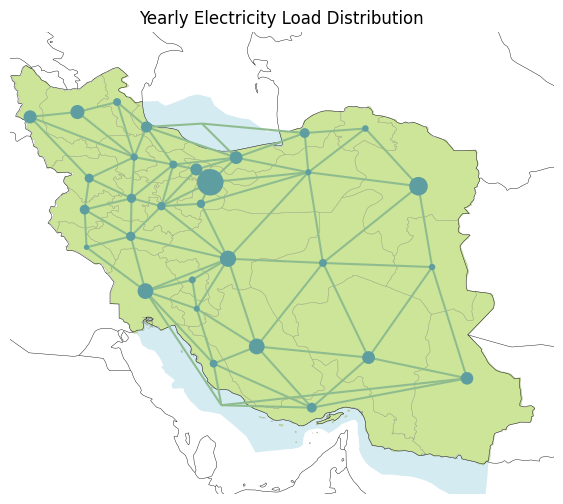

In [507]:
fig = plt.figure(figsize=(10, 6)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

load = n.loads_t.p_set.sum(axis=0).groupby(n.loads.bus).sum()
n.plot(ax=ax, bus_size=load/1e8)

ax.set_title("Yearly Electricity Load Distribution")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

In [508]:
load_ts = (n.loads_t.p_set.sum(axis=1) * n.snapshot_weightings.iloc[0, 0]).resample("D").sum()#.plot()

load_ts.divide(1e6).plot(labels=dict(value="Daily Load [TWh]"))

In [509]:
load.divide(1e6).sort_values()*3 # the load of the model is the mean for 3 hours --> Load must be multiplied with 3

bus
Ilam                           2.944117
Kohgiluyeh and Boyer-Ahmad     3.743023
Semnan                         3.881105
South Khorasan                 4.167133
North Khorasan                 4.315079
Chaharmahal and Bakhtiari      4.916724
Zanjan                         5.518369
Bushehr                        6.297549
Ardabil                        6.406043
Yazd                           6.480016
Qazvin                         6.637824
Qom                            7.170428
Markazi                        7.259196
Kurdistan                      8.329335
Hamadan                        8.723857
Lorestan                       8.837282
Kermanshah                     9.858106
Golestan                       9.941942
Hormozgan                      9.951805
Gilan                         12.669072
Alborz                        14.932639
Sistan and Baluchestan        16.175381
Kerman                        16.831273
Mazandaran                    16.841137
West Azerbaijan               17.403

In [510]:
n.snapshot_weightings.iloc[0, 0]

np.float64(3.0)

## Generation and links

### Existing Power Plants

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_1284/3946227653.py:14: DtypeWarning:

Columns (10,17,18,26,27,37,38) have mixed types. Specify dtype option on import or set low_memory=False.

/Users/morteza/DSESM-venv-312/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning:

facecolor will have no effect as it has been defined as "never".



Text(0.5, 1.0, 'Location of power plants and their primary fuel')

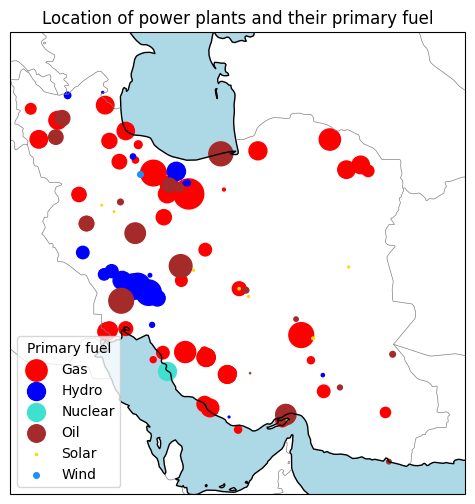

In [511]:
fuel_colors = {
    "Gas": "red",
    "Hydro": "blue",
    "Nuclear": "turquoise",
    "Oil": "brown",
    "Solar": "gold",
    "Wind": "dodgerblue",
}

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.epsg(3857))

url_power_plants = Path("data") / "global_power_plant_database.csv"
pp = pd.read_csv(url_power_plants)
pp = pp[pp["country"] == "IRN"]
geometry = gpd.points_from_xy(pp.longitude, pp.latitude) # saving geometry from long and lat of the data to create a geopanda

pp_ir = gpd.GeoDataFrame(pp, geometry=geometry, crs="WGS84")

pp_ir_3857 = pp_ir.to_crs(epsg=3857)

for fuel, color in fuel_colors.items():
    subset = pp_ir_3857[pp_ir_3857["primary_fuel"] == fuel]
    if not subset.empty:
        subset.plot(
            ax=ax,
            color=color,
            markersize=subset["capacity_mw"] / 6,
            label=fuel,
        )

ax.coastlines()
ax.add_feature(cartopy.feature.OCEAN, color="lightblue", linewidth=0.3)
ax.add_feature(cartopy.feature.BORDERS, color="grey", linewidth=0.5)

ax.legend(
    title="Primary fuel",
    loc="lower left",
    frameon=True,
)

ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())
ax.set_title("Location of power plants and their primary fuel")


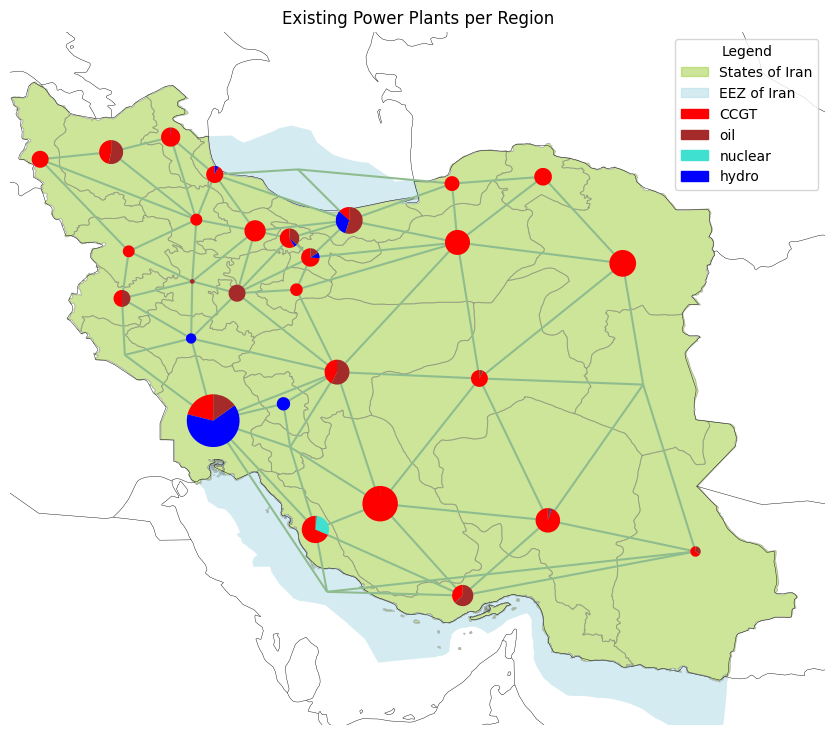

In [512]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.7)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

re_cap_potentials = n.generators.groupby(["bus", "carrier"]).p_nom.sum()
re_cap_potentials = re_cap_potentials.loc[re_cap_potentials.index.get_level_values("carrier").isin(["CCGT", "oil", "hydro", "nuclear"])]
n.plot(ax=ax, bus_size=re_cap_potentials/3e4)

ax.set_title("Existing Power Plants per Region")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

wanted_carriers = ["CCGT", "oil", "hydro", "nuclear"]

import matplotlib.patches as mpatches
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    #loc="lower left",
    frameon=True
)

### Model n (without CO2 Limit)

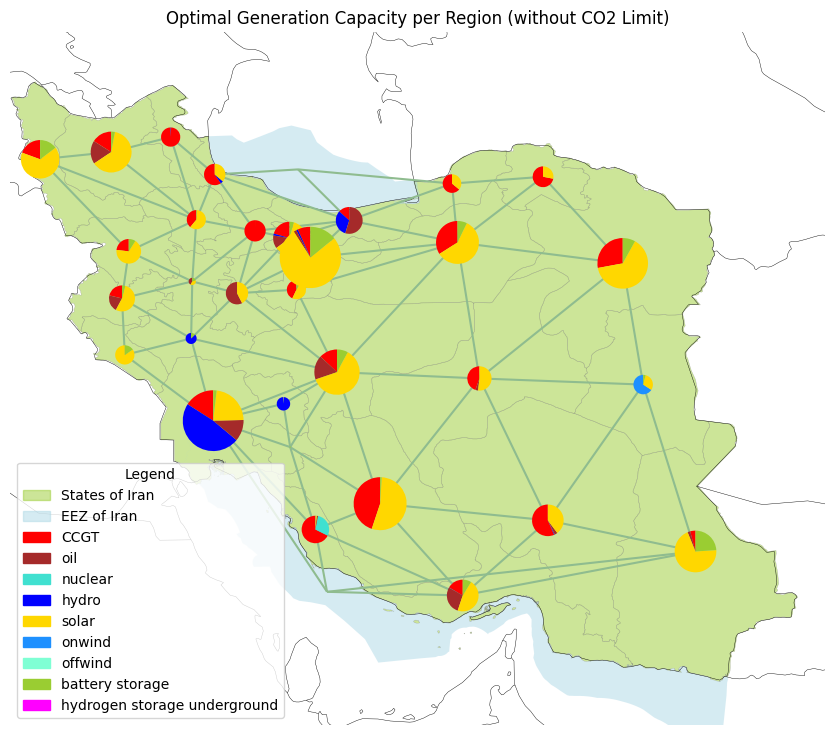

In [513]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

gen = n.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()
storages = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
capacities = pd.concat([gen, storages])
n.plot(ax=ax, bus_size=capacities/3e4)


ax.set_title("Optimal Generation Capacity per Region (without CO2 Limit)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

import matplotlib.patches as mpatches

wanted_carriers = ["CCGT", "oil", "nuclear", "hydro", "solar", "onwind", "offwind", "battery storage", "hydrogen storage underground"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    loc="lower left",
    frameon=True
)

### Model n_no_co2 (with CO2 Limit of 0)

'ax.legend(\n    handles=map_legend + carrier_legend,\n    title="Legend",\n    loc="lower left",\n    frameon=True\n)'

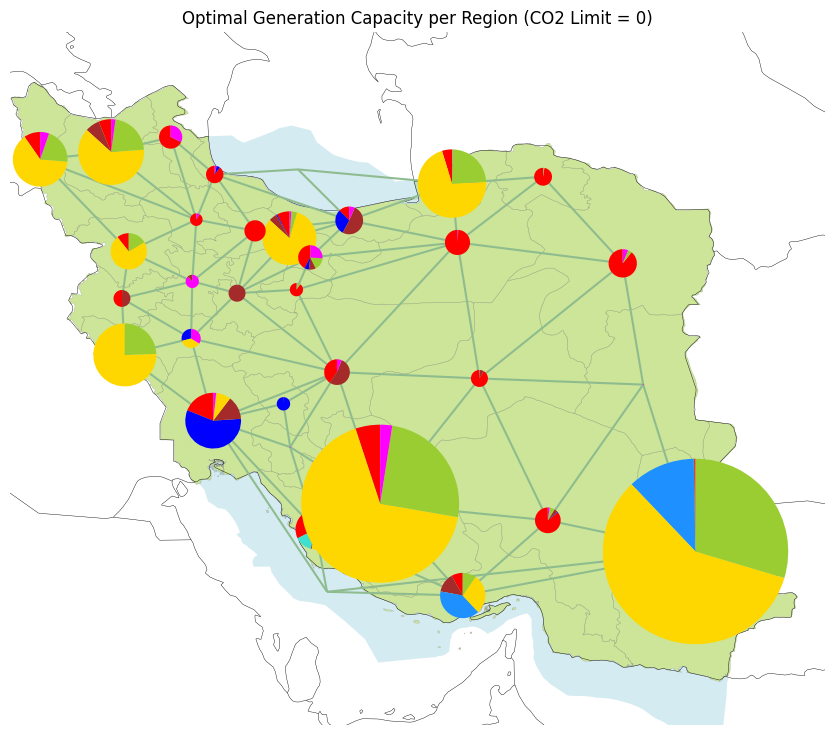

In [514]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

gen = n_no_co2.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()
storages = n_no_co2.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
capacities = pd.concat([gen, storages])

#capacities.loc[capacities.index.get_level_values("carrier").isin(["CCGT", "oil"])] = 0.0

n_no_co2.plot(ax=ax, bus_size=capacities/3e4)

ax.set_title("Optimal Generation Capacity per Region (CO2 Limit = 0)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

wanted_carriers = ["CCGT", "oil", "nuclear", "hydro", "solar", "onwind", "offwind", "battery storage", "hydrogen storage underground"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

"""ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    loc="lower left",
    frameon=True
)"""

## RE Potentials

In [515]:
re_cap_potentials = n.generators.groupby(["bus", "carrier"]).p_nom_max.mean()
re_cap_potentials = re_cap_potentials.loc[re_cap_potentials.index.get_level_values("carrier").isin(["solar", "onwind", "offwind"])]

In [516]:
re_cap_potentials.idxmin()

('Mazandaran', 'onwind')

In [517]:
#re_cap_potentials.loc[:, "solar"].sort_values()

In [518]:
re_cap_potentials.loc["Caspian Sea"]

carrier
offwind    6220.570394
Name: p_nom_max, dtype: float64

In [519]:
re_cap_potentials.loc["Mazandaran", "onwind"]

np.float64(767.4807176210561)

In [520]:
re_cap_potentials.loc["Sistan and Baluchestan", "solar"]

np.float64(383728.50838757865)

In [521]:
re_cap_potentials.loc["Sistan and Baluchestan", "onwind"]

np.float64(354857.3537591078)

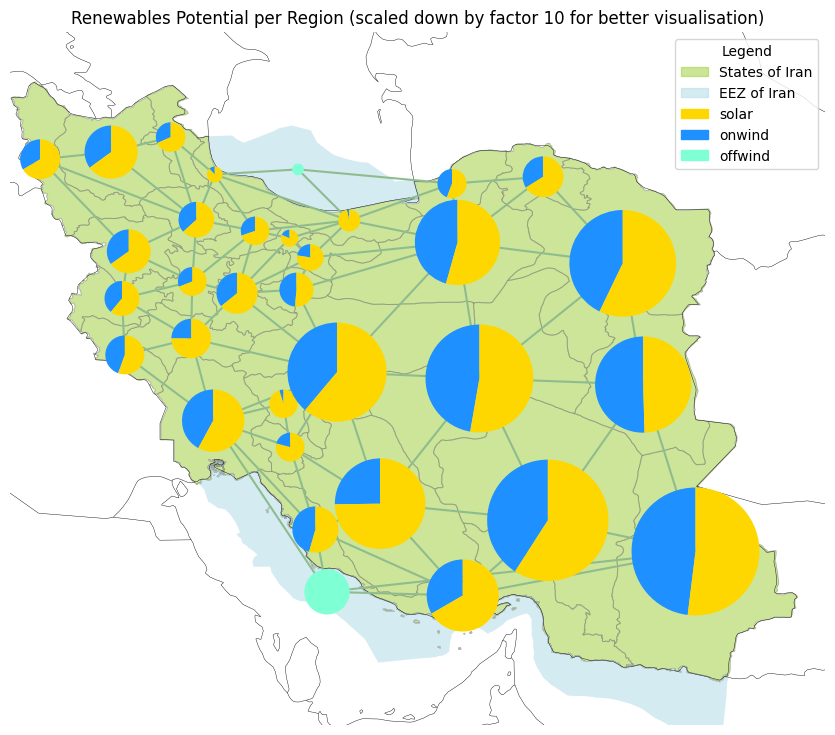

In [522]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.7)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

#re_cap_potentials = n.generators.groupby(["bus", "carrier"]).p_nom_max.mean()
#re_cap_potentials = re_cap_potentials.loc[re_cap_potentials.index.get_level_values("carrier").isin(["solar", "onwind", "offwind"])]
n.plot(ax=ax, bus_size=re_cap_potentials/3e5)

ax.set_title("Renewables Potential per Region (scaled down by factor 10 for better visualisation)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

wanted_carriers = ["solar", "onwind", "offwind"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    #loc="lower left",
    frameon=True
)

## Power Flow

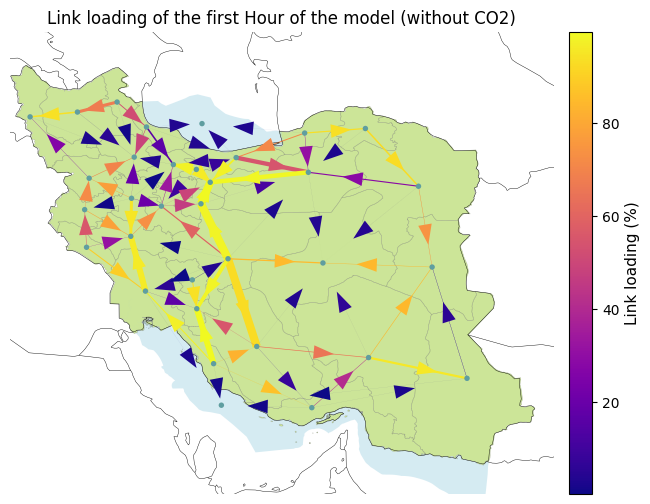

In [523]:
import numpy as np

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", alpha=0.5)

# loading showed by color
loading_pct = n.links_t.p0.iloc[0].abs() / n.links.p_nom_opt / n.links.p_max_pu * 100  # %

# widths (visible scaling)
link_w = (n.links.p_nom_opt / 1000)

# ---- pass 1: draw links (thick, no arrows) ----
n.plot(
    ax=ax,
    bus_size=1e-2,
    link_color=loading_pct,
    link_cmap="plasma",
    link_width=link_w / 1e1,     # keep line width
    link_flow=0.25,           # <-- suppress arrows
    auto_scale_branches=False,
)

import matplotlib as mpl

# --- create a ScalarMappable for the colorbar ---
norm = mpl.colors.Normalize(
    vmin=loading_pct.min(),
    vmax=loading_pct.max()
)

sm = mpl.cm.ScalarMappable(
    cmap="plasma",
    norm=norm
)
sm.set_array([])  # required for matplotlib
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.035,
    pad=0.02
)

cbar.set_label("Link loading (%)", fontsize=11)

ax.set_title("Link loading of the first Hour of the model (without CO2)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())


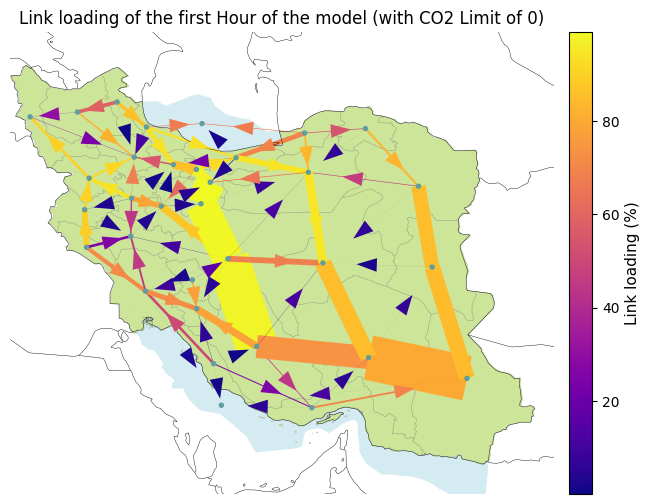

In [524]:
import numpy as np

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", alpha=0.5)

# loading showed by color
loading_pct = n_no_co2.links_t.p0.iloc[0].abs() / n_no_co2.links.p_nom_opt / n_no_co2.links.p_max_pu * 100  # %

# widths (visible scaling)
link_w = (n_no_co2.links.p_nom_opt / 1000)

# ---- pass 1: draw links (thick, no arrows) ----
n_no_co2.plot(
    ax=ax,
    bus_size=1e-2,
    link_color=loading_pct,
    link_cmap="plasma",
    link_width=link_w / 1e1,     # keep line width
    link_flow=0.25,           # <-- suppress arrows
    auto_scale_branches=False,
)

import matplotlib as mpl

# --- create a ScalarMappable for the colorbar ---
norm = mpl.colors.Normalize(
    vmin=loading_pct.min(),
    vmax=loading_pct.max()
)

sm = mpl.cm.ScalarMappable(
    cmap="plasma",
    norm=norm
)
sm.set_array([])  # required for matplotlib
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.035,
    pad=0.02
)

cbar.set_label("Link loading (%)", fontsize=11)

ax.set_title("Link loading of the first Hour of the model (with CO2 Limit of 0)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())


## Total System Cost

In [525]:
tsc_n = (
    pd.concat(
        {
            "capex": n.statistics.capex(),
            "opex": n.statistics.opex(),
        },
        axis=1,
    )
    .div(1e9)
    .round(2)
    .fillna(0.0)
)  # bn€/a

tsc_n_no_co2 = (
    pd.concat(
        {
            "capex": n_no_co2.statistics.capex(),
            "opex": n_no_co2.statistics.opex(),
        },
        axis=1,
    )
    .div(1e9)
    .round(2)
    .fillna(0.0)
)  # bn€/a

tsc_n.index = tsc_n.index.get_level_values("carrier").union(
    tsc_n_no_co2.index.get_level_values("carrier")
)

tsc_n_no_co2.index = tsc_n_no_co2.index.get_level_values("carrier").union(
    tsc_n_no_co2.index.get_level_values("carrier"))

# adding hydro to the model
tsc_n.loc["hydro", :] = 0
tsc_n_no_co2.loc["hydro", :] = 0
tsc_n_no_co2.sum().sum()

np.float64(43.690000000000005)

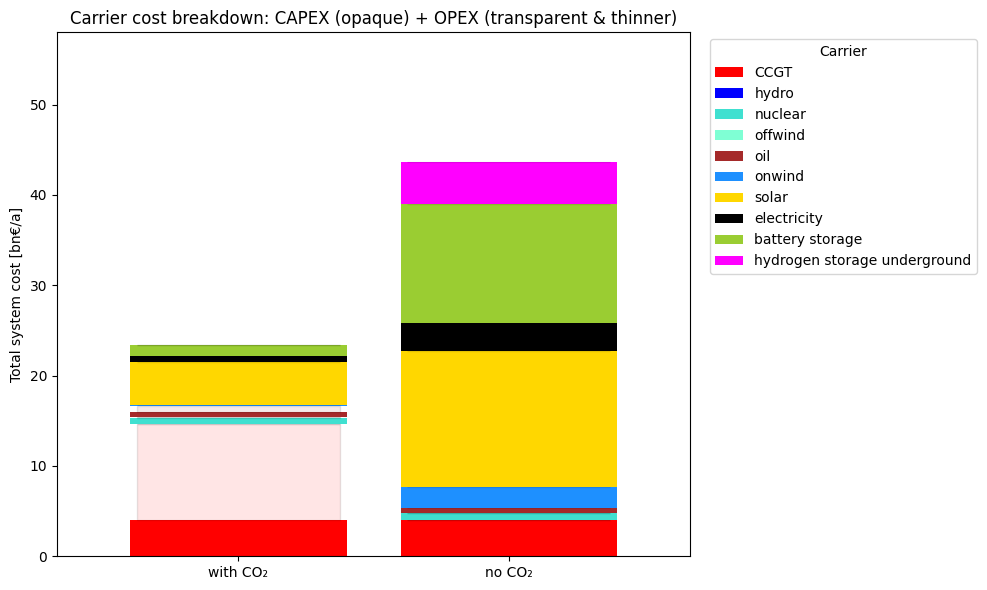

In [526]:
# --- carrier colors (PyPSA) ---
carrier_colors = n.carriers["color"]  # Series indexed by carrier

# --- make sure both tables have the same carrier index ---
carriers = tsc_n.index.get_level_values("carrier").union(
    tsc_n_no_co2.index.get_level_values("carrier")
)

# if some carriers have no defined color, give them a default
colors = {c: carrier_colors.get(c, "#999999") for c in carriers}

fig, ax = plt.subplots(figsize=(10, 6))

x = np.array([0, 1])
labels = ["with CO₂", "no CO₂"]

# bottoms for stacking
"""bottom_capex = np.zeros_like(x, dtype=float)
bottom_total = np.zeros_like(x, dtype=float)  # capex+opex stack"""

bottom = float(0)

# for model n:
for c in carriers:
        cap = tsc_n.loc[c, "capex"]
        opx = tsc_n.loc[c, "opex"]

        # 1) plot CAPEX stack (opaque)
        ax.bar(0, cap, bottom=bottom, color=colors[c], alpha=1, width=0.8)
        bottom += cap

        # 2) plot OPEX stack on top of (capex+previous opex) (transparent)
        ax.bar(0, opx, bottom=bottom, color=colors[c], alpha=0.1, width=0.75, edgecolor="black")
        bottom += opx

bottom = float(0)
# for model n_no_co2:
for c in carriers:
        cap = tsc_n_no_co2.loc[c, "capex"]
        opx = tsc_n_no_co2.loc[c, "opex"]

        # 1) plot CAPEX stack (opaque)
        ax.bar(1, cap, bottom=bottom, color=colors[c], alpha=1, width=0.8)
        bottom += cap

        # 2) plot OPEX stack on top of (capex+previous opex) (transparent)
        ax.bar(1, opx, bottom=bottom, color=colors[c], alpha=0.1, width=0.75, edgecolor="black")
        bottom += opx

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Total system cost [bn€/a]")
ax.set_title("Carrier cost breakdown: CAPEX (opaque) + OPEX (transparent & thinner)")

# legend = carriers (single entry per carrier)
handles = [mpatches.Patch(facecolor=colors[c], edgecolor="none", label=c) for c in carriers]
ax.legend(handles=handles, title="Carrier", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 58)

ax.margins(x=0.15)
plt.tight_layout()
plt.show()


In [527]:
tsc_n_no_co2

,capex,opex
carrier,,
CCGT,4.07,0.00
hydro,0.00,0.00
nuclear,0.75,0.01
offwind,0.00,0.00
oil,0.46,0.00
onwind,2.36,0.01
solar,15.02,0.00
electricity,3.11,0.00
battery storage,13.17,0.00


## Capacities built per technology

In [528]:
# generation capacities
n_capacities_per_carrier = n.generators.groupby(["carrier"]).sum().p_nom_opt.divide(1e3) # in GW
n_no_co2_capacities_per_carrier = n_no_co2.generators.groupby(["carrier"]).sum().p_nom_opt.divide(1e3) # in GW

# storage capacities
n_storage_cap = n.storage_units.groupby(["carrier"]).sum().p_nom_opt.divide(1e3) # in GW
n_no_co2_storage_cap = n_no_co2.storage_units.groupby(["carrier"]).sum().p_nom_opt.divide(1e3) # in GW

# having them all in one series
n_caps = pd.concat([n_capacities_per_carrier, n_storage_cap])  # in GW
n_no_co2_caps = pd.concat([n_no_co2_capacities_per_carrier, n_no_co2_storage_cap])  # in GW
n_no_co2_caps#.sum()

carrier
CCGT                             37.753000
hydro                            10.727500
nuclear                           1.000000
offwind                           0.000060
oil                              11.310600
onwind                           21.991034
solar                           237.910339
battery storage                  95.111006
hydrogen storage underground      7.931704
Name: p_nom_opt, dtype: float64

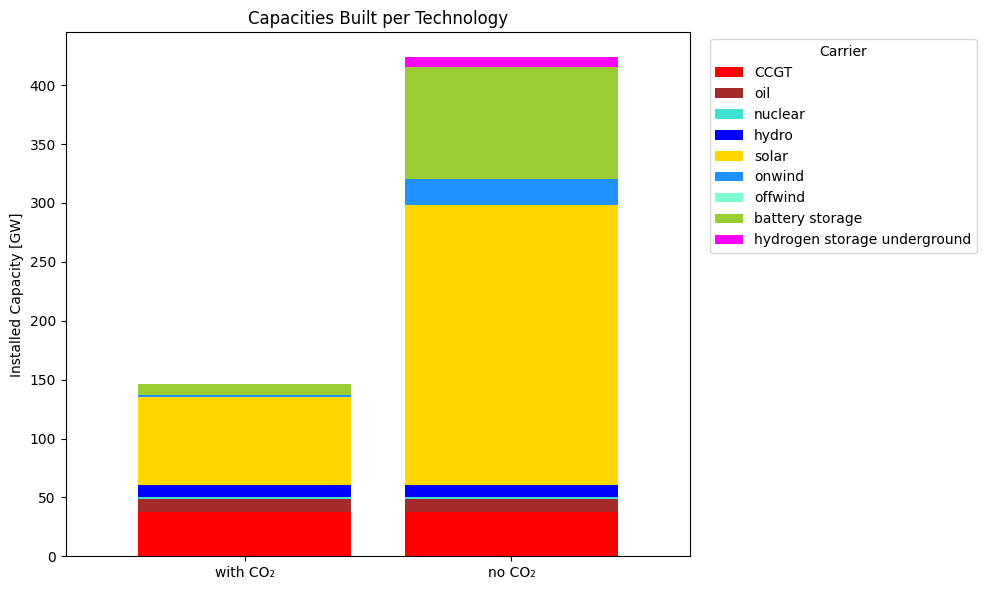

In [529]:
# --- carrier colors (PyPSA) ---
carrier_colors = n.carriers["color"]  # Series indexed by carrier

# --- make sure both tables have the same carrier index ---
carriers = n.carriers.index

# if some carriers have no defined color, give them a default
colors = {c: carrier_colors.get(c, "#999999") for c in carriers}

fig, ax = plt.subplots(figsize=(10, 6))

x = np.array([0, 1])
labels = ["with CO₂", "no CO₂"]

# bottoms for stacking
"""bottom_capex = np.zeros_like(x, dtype=float)
bottom_total = np.zeros_like(x, dtype=float)  # capex+opex stack"""

bottom = float(0)

# for model n:
for c in carriers:
        if c != "electricity":
            cap = n_caps[c]

            # 1) plot CAPEX stack (opaque)
            ax.bar(0, cap, bottom=bottom, color=colors[c], alpha=1, width=0.8)
            bottom += cap

bottom = float(0)
# for model n_no_co2:
for c in carriers:
        if c != "electricity":
            cap = n_no_co2_caps[c]

            # 1) plot CAPEX stack (opaque)
            ax.bar(1, cap, bottom=bottom, color=colors[c], alpha=1, width=0.8)
            bottom += cap

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Installed Capacity [GW]")
ax.set_title("Capacities Built per Technology")

# legend = carriers (single entry per carrier)
handles = [mpatches.Patch(facecolor=colors[c], edgecolor="none", label=c) for c in carriers if c != "electricity"]
ax.legend(handles=handles, title="Carrier", bbox_to_anchor=(1.02, 1), loc="upper left")
#ax.set_ylim(0, 420)

ax.margins(x=0.15)
plt.tight_layout()
plt.show()


## RE Time Series

In [530]:
# reading the RE generation potential data (reults of land eligibility analysis)
onwind_ts = pd.read_csv("data/wind_on_capacity_per_region_timeseries.csv", index_col=0, parse_dates=True)
offwind_ts = pd.read_csv("data/wind_off_capacity_per_region_timeseries.csv", index_col=0, parse_dates=True)
pv_ts = pd.read_csv("data/pv_capacity_per_region_timeseries.csv", index_col=0, parse_dates=True)

def make_potential_and_cf(gen_mw_df):
    p_nom_max = gen_mw_df.max(axis=0).clip(lower=0.0)                # MW
    p_max_pu  = gen_mw_df.divide(p_nom_max.replace(0.0, np.nan), axis=1).fillna(0.0)
    p_max_pu  = p_max_pu.clip(0.0, 1.0)                               # 0..1
    return p_nom_max, p_max_pu

pv_p_nom_max, pv_cf = make_potential_and_cf(pv_ts)
on_p_nom_max, on_cf = make_potential_and_cf(onwind_ts)
off_p_nom_max, off_cf = make_potential_and_cf(offwind_ts)

off_cf.resample("M").mean().plot(labels=dict(value="Capacity Factor [p.u.]"))

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_1284/3716071512.py:16: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



In [531]:
pd.options.plotting.backend = "plotly" # or "plotly" or "matplotlib"
off_cf.loc["2025-05"].plot(labels=dict(value="Capacity Factor [p.u.]"))
#off_cf.resample("D").mean().plot(labels=dict(value="Capacity Factor [p.u.]"))

In [532]:
#pv_cf.resample("M").mean().plot(labels=dict(value="Capacity Factor [p.u.]"))
pv_cf.loc["2025-05"].plot(labels=dict(value="Capacity Factor [p.u.]"))

In [533]:
#on_cf.resample("M").mean().plot(labels=dict(value="Capacity Factor [p.u.]")) # creates monthly cf for the whole year
on_cf.loc["2025-08"].resample("D").mean().plot(labels=dict(value="Capacity Factor [p.u.]"))

In [534]:
#on_cf.loc["2025-03"].resample("D").mean().plot(labels=dict(value="Capacity Factor [p.u.]")) # creates cf for only one month

## Electricity Mix

In [535]:
# generation per carrier for model n
gen_p_n = n.generators_t.p
gen_by_carr_n = gen_p_n.groupby(n.generators.carrier, axis=1).sum().sum(axis=0).divide(1e6) * n.snapshot_weightings.iloc[0, 0] # in TWh

# for the model n_no_co2
gen_p_n_no_co2 = n_no_co2.generators_t.p
gen_by_carr_n_no_co2 = gen_p_n_no_co2.groupby(n_no_co2.generators.carrier, axis=1).sum().sum(axis=0).divide(1e6) * n_no_co2.snapshot_weightings.iloc[0, 0] # in TWh

#gen_by_carr_n

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_1284/3360964689.py:3: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_1284/3360964689.py:7: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



In [536]:
gen_by_carr_n#.sum()

carrier
CCGT       221.114119
hydro       24.434790
nuclear      7.574622
offwind      0.000006
oil          4.607602
onwind       2.257996
solar      165.718879
dtype: float64

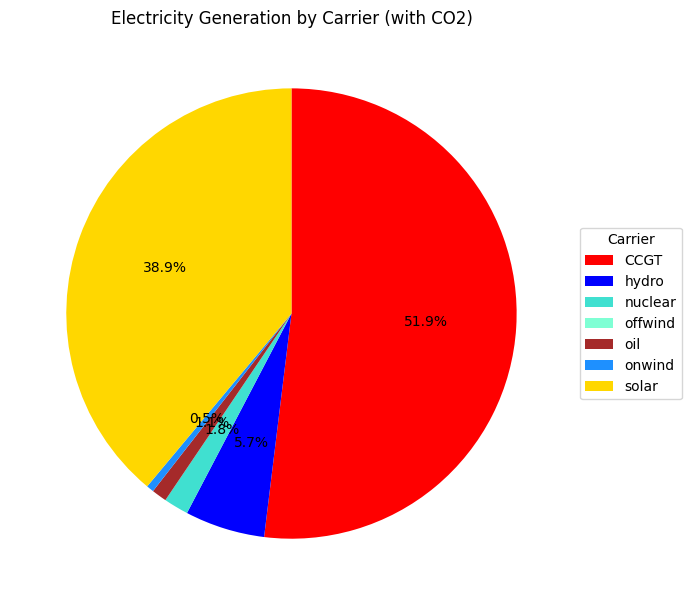

In [537]:
# Align colors with data
colors = n.carriers.color.reindex(gen_by_carr_n.index)

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    gen_by_carr_n,
    labels=None,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)

for autotext in autotexts:
    if autotext.get_text() == "0.0%":
        autotext.set_text("")

# Legend
ax.legend(
    wedges,
    gen_by_carr_n.index,
    title="Carrier",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

ax.set_title("Electricity Generation by Carrier (with CO2)")
plt.tight_layout()
plt.show()

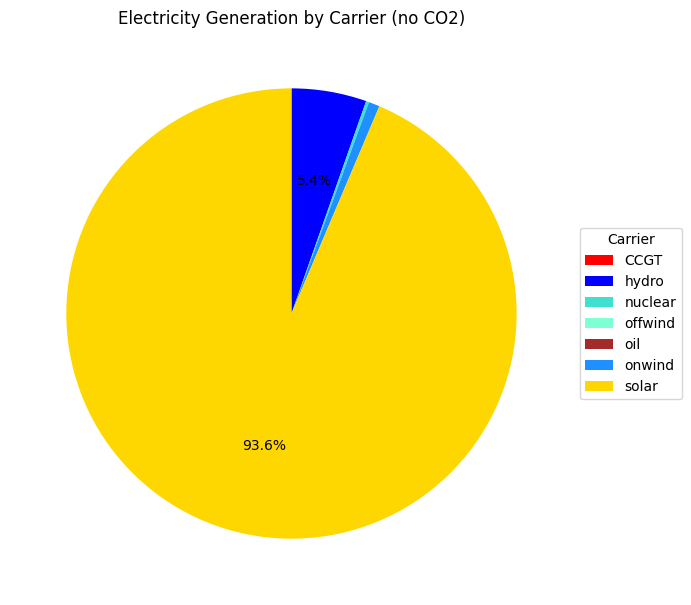

In [538]:
# Align colors with data
colors = n.carriers.color.reindex(gen_by_carr_n.index)

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    gen_by_carr_n_no_co2,
    labels=None,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)

for autotext in autotexts:
    if (autotext.get_text() == "0.2%") | (autotext.get_text() == "0.8%") | (autotext.get_text() == "0.0%"):
        autotext.set_text("")

# Legend
ax.legend(
    wedges,
    gen_by_carr_n.index,
    title="Carrier",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

ax.set_title("Electricity Generation by Carrier (no CO2)")
plt.tight_layout()
plt.show()

### Regional Distribution

In [539]:
# generation per carrier for model n
gen_p_n = n.generators_t.p
gen_by_carr_n = gen_p_n.groupby([n.generators.bus, n.generators.carrier], axis=1).sum().sum(axis=0).divide(1e3) * n.snapshot_weightings.iloc[0, 0] # in GWh

# for the model n_no_co2
gen_p_n_no_co2 = n_no_co2.generators_t.p
gen_by_carr_n_no_co2 = gen_p_n_no_co2.groupby([n_no_co2.generators.bus, n.generators.carrier], axis=1).sum().sum(axis=0).divide(1e3) * n_no_co2.snapshot_weightings.iloc[0, 0] # in GWh

gen_by_carr_n

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_1284/3011562232.py:3: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_1284/3011562232.py:7: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



bus     carrier
Alborz  CCGT       6086.087529
        hydro       122.918618
        oil         537.988404
        onwind        0.005400
        solar      6334.070398
                      ...     
Yazd    onwind        0.003381
        solar      3097.073105
Zanjan  CCGT       3873.904358
        onwind        0.001718
        solar      2004.705081
Length: 114, dtype: float64

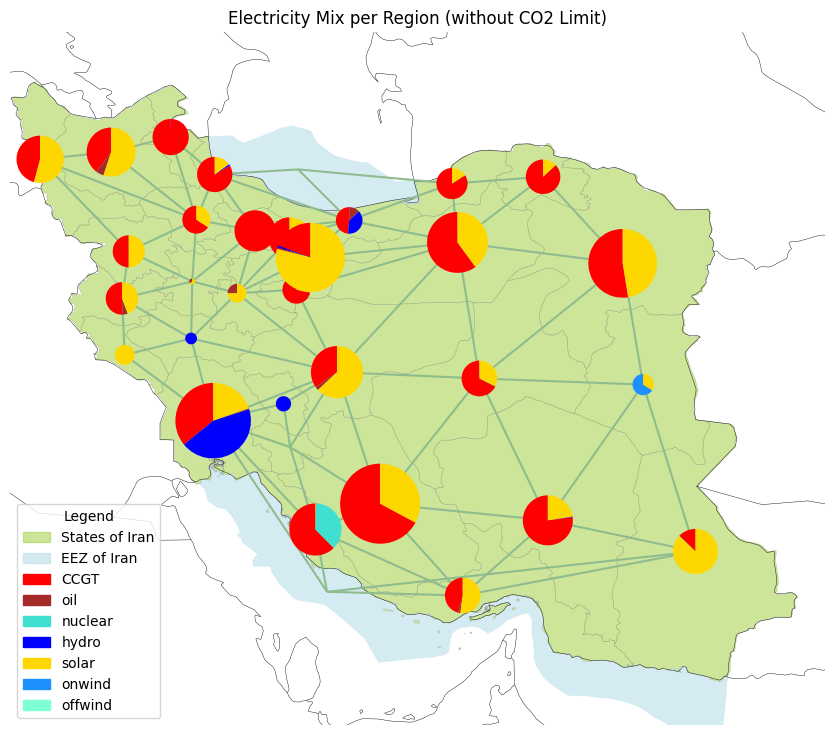

In [540]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

gen = n.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()
storages = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
capacities = pd.concat([gen, storages])
n.plot(ax=ax, bus_size=gen_by_carr_n/5e4)


ax.set_title("Electricity Mix per Region (without CO2 Limit)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

import matplotlib.patches as mpatches

wanted_carriers = ["CCGT", "oil", "nuclear", "hydro", "solar", "onwind", "offwind"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    loc="lower left",
    frameon=True
)

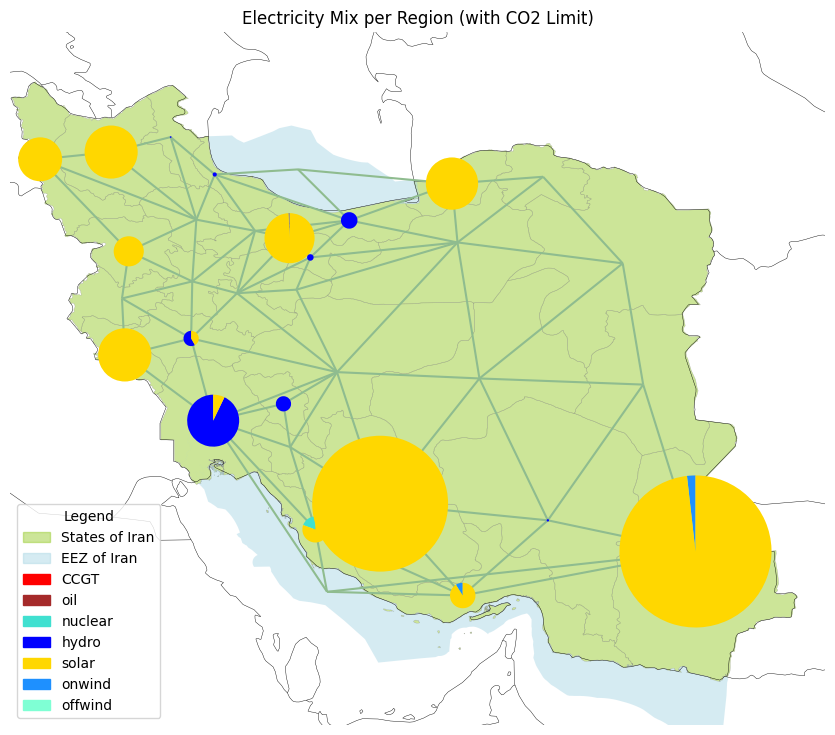

In [541]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

gen = n.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()
storages = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
capacities = pd.concat([gen, storages])
n.plot(ax=ax, bus_size=gen_by_carr_n_no_co2/5e4)


ax.set_title("Electricity Mix per Region (with CO2 Limit)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

import matplotlib.patches as mpatches

wanted_carriers = ["CCGT", "oil", "nuclear", "hydro", "solar", "onwind", "offwind"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    loc="lower left",
    frameon=True
)

In [542]:
n.links.capital_cost

name
line_Alborz__Markazi                           16358.323526
line_Alborz__Mazandaran                        13392.548961
line_Alborz__Qazvin                             7583.399549
line_Alborz__Tehran                             6097.134070
line_Ardabil__East Azerbaijan                  13200.928679
                                                   ...     
line_Semnan__Yazd                              29630.219689
line_Sistan and Baluchestan__South Khorasan    37618.332132
line_Sistan and Baluchestan__Persian Gulf      79719.364428
line_South Khorasan__Yazd                      35240.619109
line_West Azerbaijan__Zanjan                   36012.142599
Name: capital_cost, Length: 81, dtype: float64

## Energy Balance

In [543]:
n.statistics.energy_balance.iplot()

In [544]:
n_no_co2.statistics.energy_balance.iplot()

## Prices

In [545]:
# calculating the avg prices per region
avg_price = n.buses_t.marginal_price.mean(axis=0)
avg_price = avg_price.reindex(n.buses.index)
avg_price

avg_price_no_co2 = n_no_co2.buses_t.marginal_price.mean(axis=0)
avg_price_no_co2 = avg_price_no_co2.reindex(n.buses.index)
#avg_price_no_co2

In [546]:
name_map = {
    "Ardabil": "Ardebil",
    "Isfahan": "Esfahan",
    "East Azerbaijan": "East Azarbaijan",
    "West Azerbaijan": "West Azarbaijan",
    "Chaharmahal and Bakhtiari": "Chahar Mahall and Bakhtiari",
    "Kohgiluyeh and Boyer-Ahmad": "Kohgiluyeh and Buyer Ahmad",
    "Kurdistan": "Kordestan",
}

inv_name_map = {v: k for k, v in name_map.items()}  # GADM -> Load/Bus name
avg_price = avg_price.rename(index=inv_name_map)
#avg_price

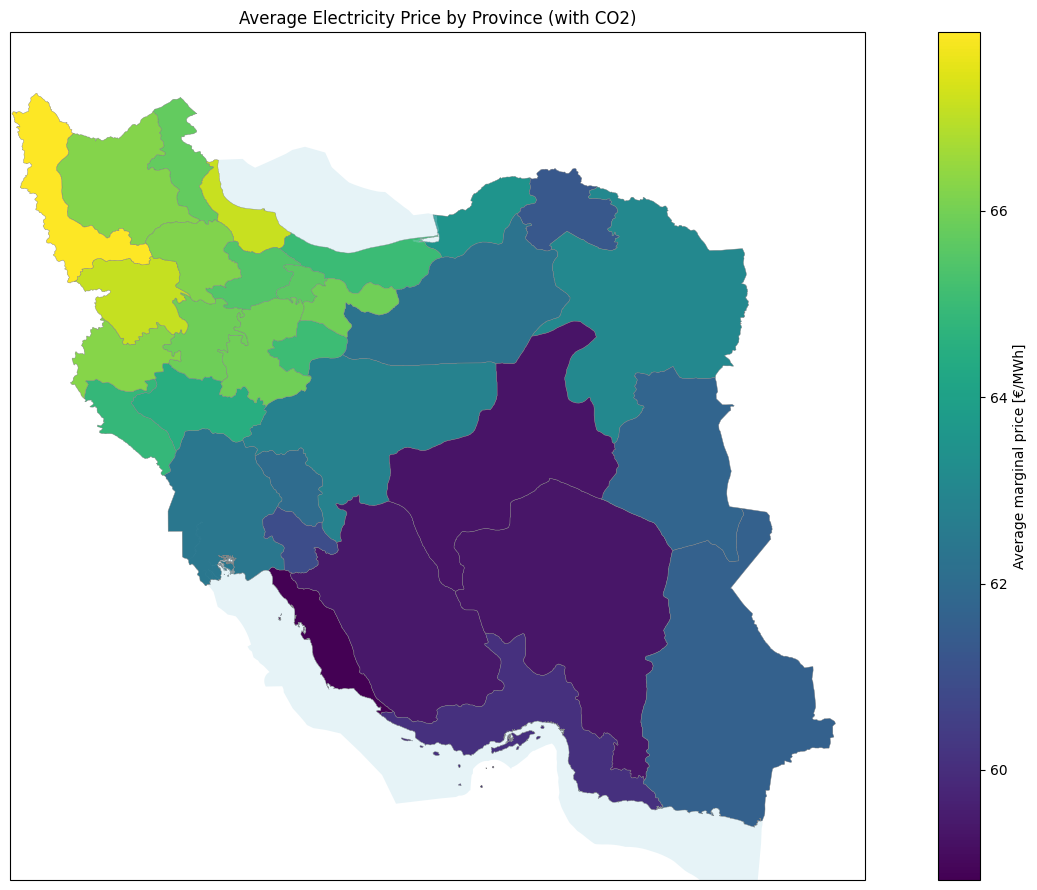

In [547]:
price_df = avg_price.rename("price").reset_index().rename(columns={"index": "province"})

gadm_ir["NAME_1"] = gadm_ir["NAME_1"].replace(inv_name_map)
gadm_price = gadm_ir.merge(price_df, left_on="NAME_1", right_on="name", how="left")


fig = plt.figure(figsize=(15, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

gadm_price.plot(
    ax=ax,
    column="price",
    cmap="viridis",
    legend=True,
    legend_kwds={"label": "Average marginal price [€/MWh]"},
    edgecolor="gray",
    linewidth=0.3
)

eez_ir.plot(ax=ax, color="lightblue", alpha=0.3)

ax.set_title("Average Electricity Price by Province (with CO2)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())
plt.tight_layout()
plt.show()


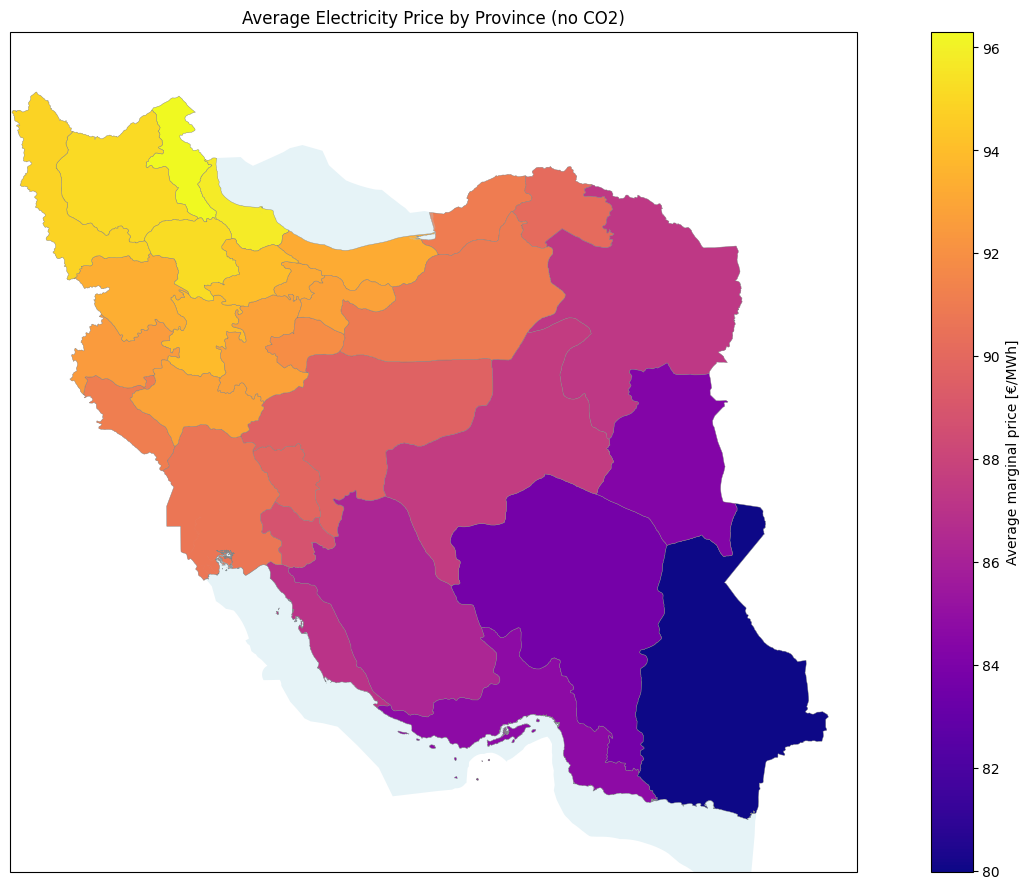

In [548]:
price_df = avg_price_no_co2.rename("price").reset_index().rename(columns={"index": "province"})

gadm_ir["NAME_1"] = gadm_ir["NAME_1"].replace(inv_name_map)
gadm_price = gadm_ir.merge(price_df, left_on="NAME_1", right_on="name", how="left")


fig = plt.figure(figsize=(15, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

gadm_price.plot(
    ax=ax,
    column="price",
    cmap="plasma",
    legend=True,
    legend_kwds={"label": "Average marginal price [€/MWh]"},
    edgecolor="gray",
    linewidth=0.3
)

eez_ir.plot(ax=ax, color="lightblue", alpha=0.3)

ax.set_title("Average Electricity Price by Province (no CO2)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())
plt.tight_layout()
plt.show()


## Price Duration Curves

In [549]:
price_ts = n.buses_t.marginal_price.mean(axis=1)
price_ts_no_co2 = n_no_co2.buses_t.marginal_price.mean(axis=1)

pdc = pd.DataFrame()

pdc["with CO2"] = price_ts.sort_values(ascending=False).reset_index(drop=True)
pdc["no CO2"] = price_ts_no_co2.sort_values(ascending=False).reset_index(drop=True)

#pdc = price_ts.sort_values(ascending=False).reset_index(drop=True)
pdc.index = pdc.index / (len(pdc) - 1) * 100 # reindexing to percentages

pdc_to_plot = pdc[1.5:] # removing the first top 1.5% for better visualisation
pdc_to_plot.plot(labels=dict(value="Avergage Price Across the Country [€/MWh]", index="Percentage of Time [%]"))

In [550]:
pdc[:1.5].plot(labels=dict(value="Avergage Price Across the Country [€/MWh]", index="Percentage of Time [%]"))

In [551]:
# plotting the price Time Series
mp_ts = pd.DataFrame()

mp_ts["with CO2"] = price_ts
mp_ts["no CO2"] = price_ts_no_co2

# ignoring the values greater than 400€/MWh for better visualization
mp_ts_clipped = mp_ts.clip(upper=500)
#mp_ts.plot()
mp_ts_clipped.plot(labels=dict(value="Average Marginal Price Across the Country [€/MWh]", index="Time"))

## Storages

In [552]:
# p_nom_opt (MW) * max_hours (h) = e_nom_opt (MWh)
# then grouping them based on carrier for the whole country (Total e_nom_opt of the country)
n_e_opt = (n.storage_units.p_nom_opt * n.storage_units.max_hours).groupby(n.storage_units.carrier).sum() # for model with CO2
n_no_co2_e_opt = (n_no_co2.storage_units.p_nom_opt * n_no_co2.storage_units.max_hours).groupby(n_no_co2.storage_units.carrier).sum() # for model no CO2

n_no_co2_e_opt/1e3 # in MWh

carrier
battery storage                  562.872717
hydrogen storage underground    5328.561409
dtype: float64

In [553]:
# taking the SOC of each model as a time series
n_storages_ts = n.storage_units_t.state_of_charge.groupby(n.storage_units.carrier, axis=1).sum() # in MWh
n_no_co2_storages_ts = n_no_co2.storage_units_t.state_of_charge.groupby(n_no_co2.storage_units.carrier, axis=1).sum() # in MWh

# creating a dataFrame to put battery storage soc to compare two models
battery_storages_ts = pd.DataFrame()

# dividing time series by e_opt to get the percentages of SOC
battery_storages_ts["with CO2"] = n_storages_ts["battery storage"].resample("D").mean() / n_e_opt[0] * 100 
battery_storages_ts["no CO2"] = n_no_co2_storages_ts["battery storage"].resample("D").mean() / n_no_co2_e_opt[0] * 100

battery_storages_ts.plot(labels=dict(value="Battery Storage - State of Charge (SOC) [%]", index="Time"))

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_1284/2259780822.py:2: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_1284/2259780822.py:3: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_1284/2259780822.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_1284/2259780822.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser

In [554]:
H2_storages_ts = pd.DataFrame()

# dividing time series by e_opt to get the percentages of SOC
#H2_storages_ts["with CO2"] = n_storages_ts["hydrogen storage underground"].resample("D").mean() / n_e_opt[1] * 100 
H2_storages_ts["with CO2"] = 0.0
H2_storages_ts["no CO2"] = n_no_co2_storages_ts["hydrogen storage underground"].resample("D").mean() / n_no_co2_e_opt[1] * 100

H2_storages_ts.plot(labels=dict(value="H2 Storage - State of Charge (SOC) [%]", index="Time"))

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_1284/1035216813.py:6: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



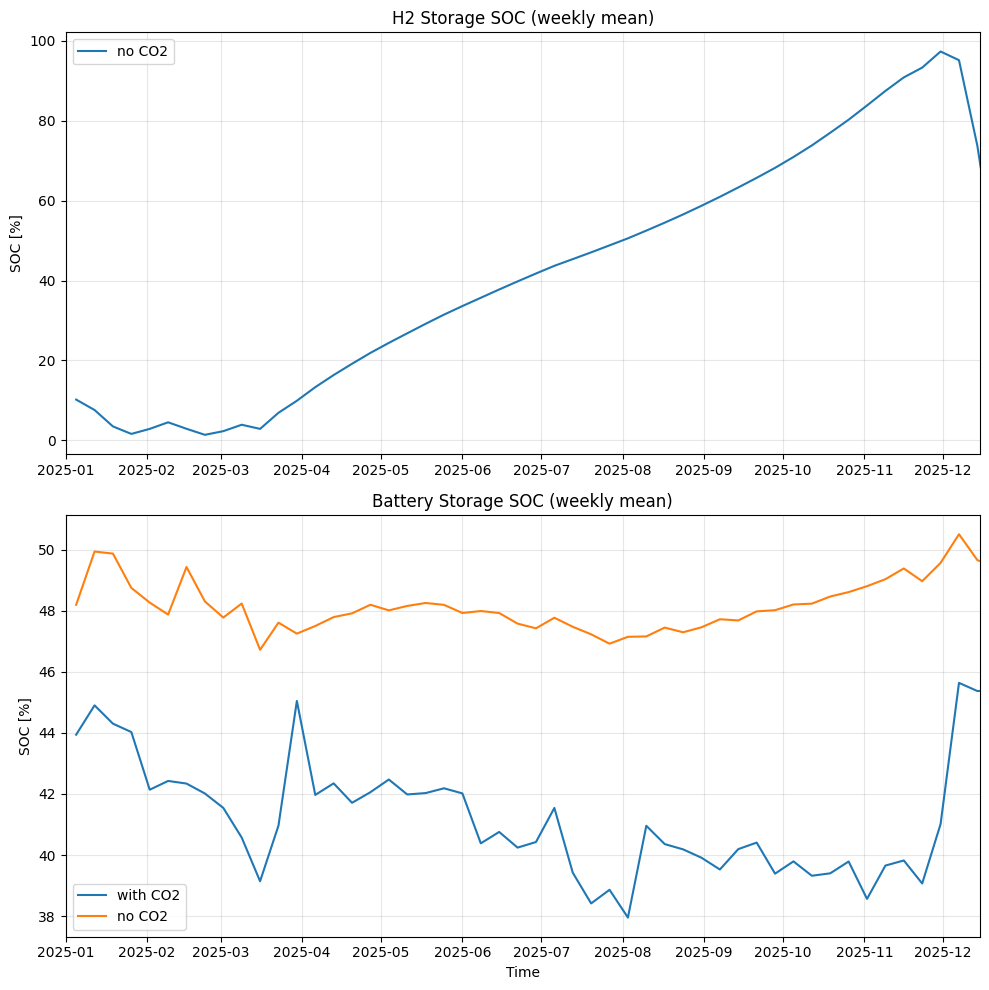

In [555]:
#import xarray as xr
#import pandas as pd
#import matplotlib.pyplot as plt

def get_storage_soc_xr(filename, carrier_exact):
    ds = xr.open_dataset(filename)

    # time index 
    time = ds["snapshots_snapshot"].to_pandas()

    # mapping
    car = ds["storage_units_carrier"].to_pandas()
    p_nom_opt = ds["storage_units_p_nom_opt"].to_pandas()
    max_hours = ds["storage_units_max_hours"].to_pandas()

    # built units filter 
    built = p_nom_opt[p_nom_opt.fillna(0.0) > 1e-3].index

    # select carrier + built
    units = car[(car == carrier_exact)].index.intersection(built)
    if len(units) == 0:
        return None, None

    soc = ds["storage_units_t_state_of_charge"].to_pandas()
    soc.index = time

    total_soc = soc[units].sum(axis=1)
    total_capacity = (p_nom_opt.loc[units] * max_hours.loc[units]).sum()

    return total_soc, total_capacity

files = {"with CO2": "pypsa_model_n.nc", "no CO2": "pypsa_model_n_no_co2.nc"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

for label, fname in files.items():
    h2_series, h2_cap = get_storage_soc_xr(fname, "hydrogen storage underground")
    bat_series, bat_cap = get_storage_soc_xr(fname, "battery storage")

    if h2_series is not None:
        s_weekly = h2_series.resample("W").mean()
        ax1.plot(s_weekly.index, s_weekly / h2_cap * 100, label=label)

    if bat_series is not None:
        s_weekly = bat_series.resample("W").mean()
        ax2.plot(s_weekly.index, s_weekly / bat_cap * 100, label=label)

ax1.set_title("H2 Storage SOC (weekly mean)")
ax1.set_ylabel("SOC [%]")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title("Battery Storage SOC (weekly mean)")
ax2.set_ylabel("SOC [%]")
ax2.set_xlabel("Time")
ax2.legend()
ax2.grid(True, alpha=0.3)
cut_end = "2025-12-15"
ax1.set_xlim(pd.to_datetime("2025-01-01"), pd.to_datetime(cut_end))
ax2.set_xlim(pd.to_datetime("2025-01-01"), pd.to_datetime(cut_end))


plt.tight_layout()
plt.show()

## Rate of Curtailment

In [556]:
n.statistics.curtailment(components='Generator', carrier=["onwind", "solar", "offwind"])
n_no_co2.statistics.curtailment(components='Generator', carrier=["onwind", "solar", "offwind"])

carrier
offwind    5.180966e+01
onwind     2.450459e+07
solar      1.402290e+08
dtype: float64

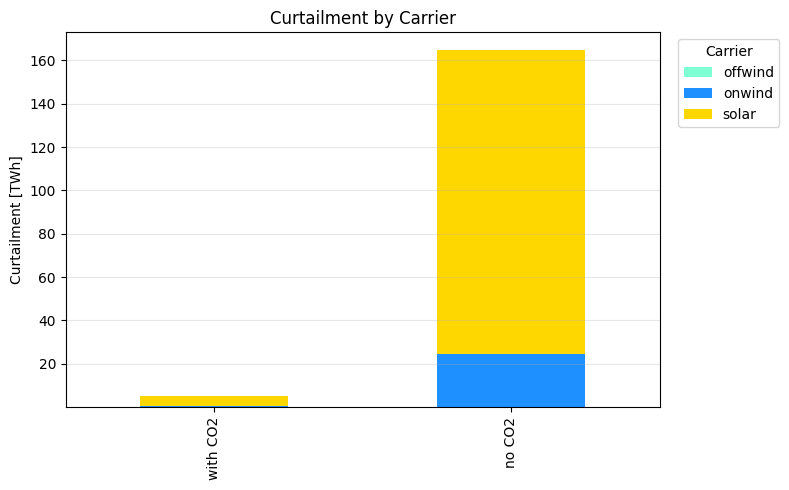

In [557]:
pd.options.plotting.backend = "matplotlib" # or "plotly" or "matplotlib"

# --- 1) fetch curtailment (Series indexed by carrier) ---
curt_with = n.statistics.curtailment(components='Generator', carrier=["onwind", "solar", "offwind"])
curt_no   = n_no_co2.statistics.curtailment(components='Generator', carrier=["onwind", "solar", "offwind"])

# Ensure they are plain Series (and name them for the resulting DataFrame index)
curt_with = pd.Series(curt_with).rename("with CO2")
curt_no   = pd.Series(curt_no).rename("no CO2")

# --- 2) combine into DataFrame: rows = model scenarios, cols = carriers ---
df_curt = pd.DataFrame([curt_with, curt_no])
# If some carriers are missing in one result, fill with 0
df_curt = df_curt.fillna(0)

# Optional: remove carriers that are zero across both scenarios
df_curt = df_curt.loc[:, (df.sum(axis=0) > 0)]
df_curt = df_curt.divide(1e6)
# --- 3) get colors aligned with df.columns (carriers) ---
# n.carriers.color is a Series indexed by carrier name
colors_series = n.carriers.color.reindex(df.columns)

# Provide a fallback color if some carriers have no color defined
fallback = "#777777"
colors = [colors_series.get(c, fallback) if pd.notna(colors_series.get(c)) else fallback for c in df.columns]

# --- 4) plot stacked bar ---
fig, ax = plt.subplots(figsize=(8, 5))

df_curt.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

ax.set_ylabel("Curtailment [TWh]")
ax.set_xlabel("")
ax.set_title("Curtailment by Carrier")
ax.grid(axis="y", alpha=0.3)

# move legend outside to the right
ax.legend(title="Carrier", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()


In [558]:
df_curt # in TWh

carrier,offwind,onwind,solar
with CO2,0.000002,0.284805,4.643877
no CO2,0.000052,24.504591,140.228957


In [559]:
# generation of each carrier
gen_with = n.statistics.energy_balance(components="Generator", carrier=["offwind", "onwind", "solar"])
gen_no = n_no_co2.statistics.energy_balance(components="Generator", carrier=["offwind", "onwind", "solar"])

gen_with.index = gen_with.index.get_level_values(0)
gen_no.index = gen_no.index.get_level_values(0)

#gen_with.drop("bus_carrier")
gen_with = pd.Series(gen_with).rename("with CO2")
gen_no   = pd.Series(gen_no).rename("no CO2")

# --- 2) combine into DataFrame: rows = model scenarios, cols = carriers ---
df_gen = pd.DataFrame([gen_with, gen_no])
# If some carriers are missing in one result, fill with 0
df_gen = df_gen.fillna(0)
df_gen = df_gen.divide(1e6) # in TWh
df_gen

carrier,offwind,onwind,solar
with CO2,0.000006,2.257996,165.718879
no CO2,0.000039,3.546938,423.427827


In [560]:
# curtailment rate in percent
df_rate_curt = df_curt / (df_curt + df_gen) * 100

df_rate_curt

carrier,offwind,onwind,solar
with CO2,28.350900,11.200437,2.725876
no CO2,56.917862,87.355633,24.878430


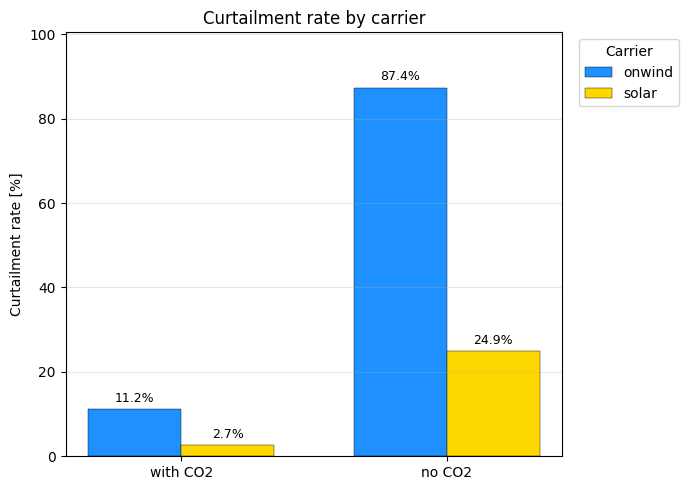

In [561]:
import numpy as np
import matplotlib.pyplot as plt

# Data: df_rate_curt (rows=scenarios, columns=carriers)
# e.g. df_rate_curt =
#               offwind    onwind     solar
# with CO2     28.3509   11.200437   2.725876
# no CO2       56.917862 87.355633  24.878430

# --- 1) choose carriers to plot (order determines stacking left->right) ---
carriers_to_plot = ["onwind", "solar"]

# Ensure the columns exist and are in the requested order
df_plot = df_rate_curt.reindex(columns=carriers_to_plot).fillna(0)

# --- 2) colors from PyPSA carriers (fallback if undefined) ---
colors_series = n.carriers.color.reindex(carriers_to_plot)
colors = [colors_series.get(c, "#777777") if pd.notna(colors_series.get(c)) else "#777777" for c in carriers_to_plot]

# --- 3) plotting layout: grouped bars per scenario ---
n_groups = len(df_plot.index)                 # e.g. 2 (with CO2, no CO2)
n_bars = len(carriers_to_plot)                # e.g. 2 (onwind, solar)
x = np.arange(n_groups)                       # group x positions
bar_width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

# center the bars within each group
offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * bar_width

for i, carrier in enumerate(carriers_to_plot):
    vals = df_plot[carrier].values
    ax.bar(x + offsets[i], vals, width=bar_width, color=colors[i], label=carrier, edgecolor="k", linewidth=0.3)

# --- 4) labels / ticks / legend ---
ax.set_xticks(x)
ax.set_xticklabels(df_plot.index)           # should be ["with CO2", "no CO2"]
ax.set_ylabel("Curtailment rate [%]")
ax.set_ylim(0, max(df_plot.max().max() * 1.15, 1))  # give some headroom
ax.set_title("Curtailment rate by carrier")

# legend using the carrier colors
ax.legend(title="Carrier", loc="upper left", bbox_to_anchor=(1.02, 1))

# annotate values above bars
for i, carrier in enumerate(carriers_to_plot):
    for j, v in enumerate(df_plot[carrier].values):
        ax.text(x[j] + offsets[i], v + (ax.get_ylim()[1] * 0.01), f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## CO2 Emissions and Shadow Prices

In [600]:
emissions_n = (
    n.generators_t.p
    / n.generators.efficiency
    * n.generators.carrier.map(n.carriers.co2_emissions)
)  # t/h

emissions_n = emissions_n.groupby(n.generators.carrier, axis=1).sum().divide(1e6) # in Mio. tCO2
emissions_n = emissions_n.sum(axis=0)
emissions_n

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_1284/1632635144.py:7: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



carrier
CCGT       25.602688
hydro       0.000000
nuclear     0.000000
offwind     0.000000
oil         1.128204
onwind      0.000000
solar       0.000000
dtype: float64

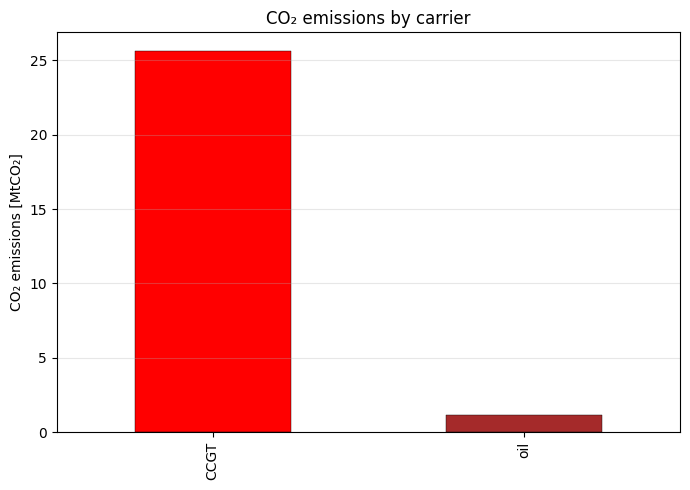

In [601]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1) keep only carriers with non-zero emissions (optional but recommended) ---
em_plot = emissions_n[emissions_n > 0]

# --- 2) align colors with carriers ---
colors = n.carriers.color.reindex(em_plot.index)

# fallback color if any carrier has no color defined
colors = colors.fillna("#777777")

# --- 3) plot ---
fig, ax = plt.subplots(figsize=(7, 5))

em_plot.plot(
    kind="bar",
    color=colors,
    ax=ax,
    edgecolor="k",
    linewidth=0.3
)

ax.set_ylabel("CO₂ emissions [MtCO₂]")
ax.set_xlabel("")
ax.set_title("CO₂ emissions by carrier")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [598]:
emissions_n_no_co2 = (
    n_no_co2.generators_t.p
    / n_no_co2.generators.efficiency
    * n_no_co2.generators.carrier.map(n_no_co2.carriers.co2_emissions)
)  # t/h

emissions_n_no_co2 = emissions_n_no_co2.groupby(n_no_co2.generators.carrier, axis=1).sum().divide(1e6) # in Mio. tCO2
emissions_n_no_co2 = emissions_n_no_co2.sum(axis=0)
emissions_n_no_co2

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_1284/2225165049.py:7: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



carrier
CCGT       0.0
hydro      0.0
nuclear    0.0
offwind    0.0
oil        0.0
onwind     0.0
solar      0.0
dtype: float64

In [ ]:
n_no_co2.global_constraints

,type,investment_period,bus,carrier_attribute,sense,constant,mu
name,,,,,,,
CO2Limit,primary_energy,NaN,,co2_emissions,<=,0.0,-15389.278301


In [594]:
# 1) read the mu from the global constraint (replace "CO2Limit" if yours has another name)
mu = n_no_co2.global_constraints.at["CO2Limit", "mu"]
print("raw mu value:", mu)

# 2) conventional carbon price (positive, in €/tCO2)
carbon_price_eur_per_t = -mu
print(f"Carbon shadow price = {-mu:.2f} €/tCO2")

# 3) check total emissions (tonnes)
total_co2_t = emissions_n = (
    n.generators_t.p
    / n.generators.efficiency
    * n.generators.carrier.map(n.carriers.co2_emissions)
).sum().sum()  # t/h
print(f"Total CO2 emissions (t): {total_co2_t:.3f}")

# 4) check carrier emission factors and implied marginal cost (€/MWh) per carrier
#   (assumes carrier.co2_emissions is in tCO2/MWh)
carriers = n.carriers.copy()
if "co2_emissions" in carriers.columns:
    carriers["implied_cost_per_MWh"] = carriers["co2_emissions"] * carbon_price_eur_per_t
    print("\nCarrier emission factors and implied carbon cost per MWh:")
    print(carriers[["co2_emissions", "implied_cost_per_MWh"]])
else:
    print("No 'co2_emissions' found in n.carriers — check your units/column names.")

# 5) quick sanity: compare implied carbon per MWh to fuel variable costs of a generator type (example)
#    find representative generator carriers (e.g. CCGT)
if "CCGT" in n.carriers.index:
    co2_per_MWh_ccgt = n.carriers.at["CCGT", "co2_emissions"]
    implied_ccgt = co2_per_MWh_ccgt * carbon_price_eur_per_t
    print(f"\nImplied carbon cost for CCGT: {implied_ccgt:.1f} €/MWh (co2 factor {co2_per_MWh_ccgt} tCO2/MWh)")


raw mu value: -15389.278300659951
Carbon shadow price = 15389.28 €/tCO2
Total CO2 emissions (t): 26730891.711

Carrier emission factors and implied carbon cost per MWh:
                              co2_emissions  implied_cost_per_MWh
name                                                             
CCGT                                 0.1980           3047.077104
oil                                  0.2571           3956.583451
nuclear                              0.0000              0.000000
hydro                                0.0000              0.000000
solar                                0.0000              0.000000
onwind                               0.0000              0.000000
offwind                              0.0000              0.000000
battery storage                      0.0000              0.000000
hydrogen storage underground         0.0000              0.000000
electricity                          0.0000              0.000000

Implied carbon cost for CCGT: 3047.1 €